In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import datetime as dt

In [3]:
start = dt.datetime(2021,7,1)
end = dt.datetime(2022,1,28)

stk_data = yf.download("RELIANCE.NS", start=start, end=end)

[*********************100%***********************]  1 of 1 completed


In [4]:
stk_data

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366821,979.891108,969.858078,972.110387,11702287
2021-07-06,966.809509,977.775284,964.716489,975.978034,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594


In [5]:
# The dataframe is not normal columns, it’s a MultiIndex (two-level columns).
# So, flattening the columns:

stk_data.columns = stk_data.columns.get_level_values(0)

In [6]:
stk_data

Price,Close,High,Low,Open,Volume
Date,,,,,
2021-07-01,954.592468,966.058736,953.250158,963.715439,12534407
2021-07-02,968.743286,970.495102,952.317341,954.160145,14086620
2021-07-05,978.366821,979.891108,969.858078,972.110387,11702287
2021-07-06,966.809509,977.775284,964.716489,975.978034,10070124
2021-07-07,960.098145,968.151889,954.615287,968.151889,10454892
...,...,...,...,...,...
2022-01-20,1127.269653,1142.057580,1117.054587,1137.552961,16494486
2022-01-21,1127.451538,1138.553855,1115.689559,1115.689559,13338594
2022-01-24,1081.973022,1139.691297,1071.598729,1126.154576,21868937


In [7]:
stk_data=stk_data[["Open", "High", "Low", "Close"]]

In [8]:
stk_data

Price,Open,High,Low,Close
Date,,,,
2021-07-01,963.715439,966.058736,953.250158,954.592468
2021-07-02,954.160145,970.495102,952.317341,968.743286
2021-07-05,972.110387,979.891108,969.858078,978.366821
2021-07-06,975.978034,977.775284,964.716489,966.809509
2021-07-07,968.151889,968.151889,954.615287,960.098145
...,...,...,...,...
2022-01-20,1137.552961,1142.057580,1117.054587,1127.269653
2022-01-21,1115.689559,1138.553855,1115.689559,1127.451538
2022-01-24,1126.154576,1139.691297,1071.598729,1081.973022


In [9]:
column="Close"

In [10]:
from sklearn.preprocessing import MinMaxScaler
Ms = MinMaxScaler()
data1 = Ms.fit_transform(stk_data[[column]])
print("Len:", data1.shape)

Len: (144, 1)


In [11]:
len(data1)

144

### Train - Test Split

In [12]:
training_size = round(len(data1) * 0.80)
print(training_size)

X_train = data1[:training_size]
X_test = data1[training_size:]
print("X_train length:", X_train.shape)
print("X_test length:", X_test.shape)

y_train = data1[:training_size]
y_test = data1[training_size:]
print("y_train length:", y_train.shape)
print("y_test length:", y_test.shape)

115
X_train length: (115, 1)
X_test length: (29, 1)
y_train length: (115, 1)
y_test length: (29, 1)


In [43]:
import pandas as pd

Actual_y_train = pd.DataFrame(index=range(len(y_train)), columns=stk_data.columns)

for i in range(len(y_train)):
    Actual_y_train.iloc[i] = y_train[i]

Actual_y_train  

Price,Open,High,Low,Close
0,0.089943,0.089943,0.089943,0.089943
1,0.134592,0.134592,0.134592,0.134592
2,0.164956,0.164956,0.164956,0.164956
3,0.12849,0.12849,0.12849,0.12849
4,0.107315,0.107315,0.107315,0.107315
...,...,...,...,...
110,0.608212,0.608212,0.608212,0.608212
111,0.537434,0.537434,0.537434,0.537434
112,0.495083,0.495083,0.495083,0.495083
113,0.485106,0.485106,0.485106,0.485106


### Model Creation

<h5 style="color:darkblue;"> 
• MSE (Mean Squared Error) → average of squared differences between actual and predicted values (penalizes large errors more) <br> 
          --> mse = mean_squared_error(y_Test, predicted_stock_price_test_ori)<br><br>

• RMSE (Root Mean Squared Error) → square root of MSE, gives error in same unit as original data (easier to interpret)<br>
          --> rmse = np.sqrt(mse)<br><br>

• MAPE (Mean Absolute Percentage Error) → average percentage error between actual and predicted values (easy to understand in %)<br>
          --> print("MAPE-Testset:", mean_absolute_percentage_error(y_Test, predicted_stock_price_test_ori)) </h5>

In [13]:
# Import required libraries
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from stockFunctions import rmsemape

# Define parameters
trends = ['n', 't', 'c', 'ct']  # no trend, trend, constant, constant+trend
lags = [1,2,3,4]                # number of past values


# Loop through lag and trend combinations
for i in lags:

    for td in trends:

        # Build model
        model = AutoReg(X_train, lags=i, trend=td)
        model_fit = model.fit()

        # Make predictions
        y_pred = model_fit.predict(start=len(X_train), end=len(data1)-1)
        
        # Print results
        print("Lag={}, Trend={}".format(i,td))
        rmsemape(y_test, y_pred)
        print("*****************")

Lag=1, Trend=n
RMSE-Testset: 0.11138755836849039
MAPE-Testset: 0.1608436155222516
*****************
Lag=1, Trend=t
RMSE-Testset: 0.13682784503245704
MAPE-Testset: 0.22405254402931035
*****************
Lag=1, Trend=c
RMSE-Testset: 0.09690366968161596
MAPE-Testset: 0.15606335143905958
*****************
Lag=1, Trend=ct
RMSE-Testset: 0.09477097646911632
MAPE-Testset: 0.1577506626409289
*****************
Lag=2, Trend=n
RMSE-Testset: 0.11038841726590781
MAPE-Testset: 0.15957287529775926
*****************
Lag=2, Trend=t
RMSE-Testset: 0.12663179694027038
MAPE-Testset: 0.20744694097765148
*****************
Lag=2, Trend=c
RMSE-Testset: 0.09684481910280301
MAPE-Testset: 0.15484196101447942
*****************
Lag=2, Trend=ct
RMSE-Testset: 0.09431079131875217
MAPE-Testset: 0.15418895358082885
*****************
Lag=3, Trend=n
RMSE-Testset: 0.11391426421414852
MAPE-Testset: 0.16233584918758412
*****************
Lag=3, Trend=t
RMSE-Testset: 0.1659660656619091
MAPE-Testset: 0.27991367323167043
*********

In [14]:
len(y_pred)

29

In [15]:
# Best model: Lag=2, Trend='ct'
# Reason: Lower is better for both. Lowest RMSE with balanced MAPE → gives stable and accurate predictions

i=2
td='ct'

# Build model
model = AutoReg(X_train, lags=i, trend=td)
model_fit = model.fit()

# Make predictions
y_pred = model_fit.predict(start=len(X_train), end=len(data1)-1)

print("Lag={}, Trend={}".format(i, td))
rmsemape(y_test, y_pred)
print("*****************")

Lag=2, Trend=ct
RMSE-Testset: 0.09431079131875217
MAPE-Testset: 0.15418895358082885
*****************


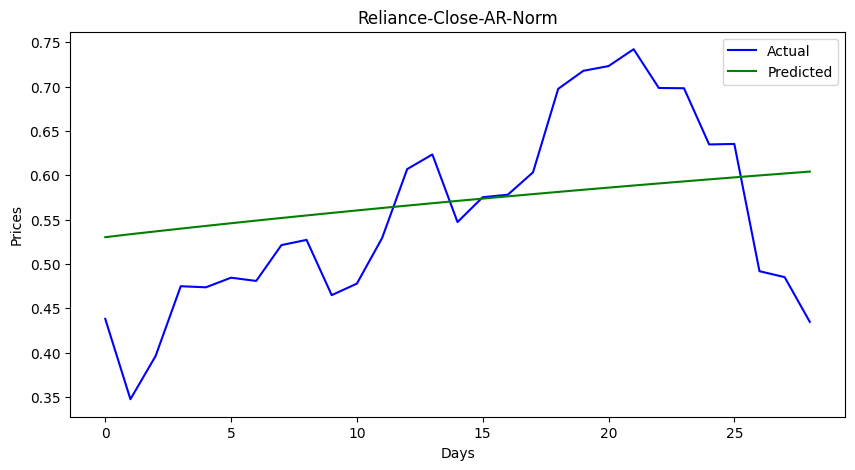

In [16]:
from stockFunctions import graph
graph(y_test, y_pred, "Actual", "Predicted", "Reliance-Close-AR-Norm", "Days", "Prices")

In [17]:
len(data1)

144

In [18]:
y_test

array([[0.43808805],
       [0.34749855],
       [0.39616667],
       [0.4749119 ],
       [0.47369173],
       [0.48453114],
       [0.48086986],
       [0.52128335],
       [0.52716967],
       [0.46486245],
       [0.47785525],
       [0.52910776],
       [0.60699179],
       [0.62350144],
       [0.54726896],
       [0.57526391],
       [0.57813562],
       [0.60333089],
       [0.69743762],
       [0.71782385],
       [0.72313552],
       [0.74215753],
       [0.69844211],
       [0.69815517],
       [0.63477183],
       [0.63534571],
       [0.49185254],
       [0.48517704],
       [0.43471371]])

### Coverting to original data

In [19]:
from stockFunctions import conversionSingle
aTestNormTable = conversionSingle(y_test, [column])

In [20]:
aTestNormTable

,Close
0,0.438088
1,0.347499
2,0.396167
3,0.474912
4,0.473692
5,0.484531
6,0.48087
7,0.521283
8,0.52717
9,0.464862


In [21]:
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)

In [22]:
actual_stock_price_test_ori

array([[1064.9329834 ],
       [1036.22167969],
       [1051.64648438],
       [1076.60388184],
       [1076.21716309],
       [1079.65258789],
       [1078.4921875 ],
       [1091.30078125],
       [1093.16638184],
       [1073.41882324],
       [1077.53674316],
       [1093.78063965],
       [1118.46508789],
       [1123.69763184],
       [1099.53662109],
       [1108.40930176],
       [1109.31945801],
       [1117.30480957],
       [1147.13085938],
       [1153.59204102],
       [1155.2755127 ],
       [1161.30432129],
       [1147.44921875],
       [1147.35827637],
       [1127.26965332],
       [1127.45153809],
       [1081.97302246],
       [1079.8572998 ],
       [1063.86352539]])

In [23]:
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [24]:
actual_stock_price_test_oriA

,Close
0,1064.932983
1,1036.22168
2,1051.646484
3,1076.603882
4,1076.217163
5,1079.652588
6,1078.492188
7,1091.300781
8,1093.166382
9,1073.418823


In [25]:
from stockFunctions import conversionSingle

aTestNormTable = conversionSingle(y_test, [column])
actual_stock_price_test_ori = Ms.inverse_transform(aTestNormTable)
actual_stock_price_test_oriA = conversionSingle(actual_stock_price_test_ori, [column])

In [26]:
from stockFunctions import conversionSingle

pTestNormTable = conversionSingle(y_pred, [column])
predicted_stock_price_test_ori = Ms.inverse_transform(pTestNormTable)
predicted_stock_price_test_oriP = conversionSingle(predicted_stock_price_test_ori, [column])

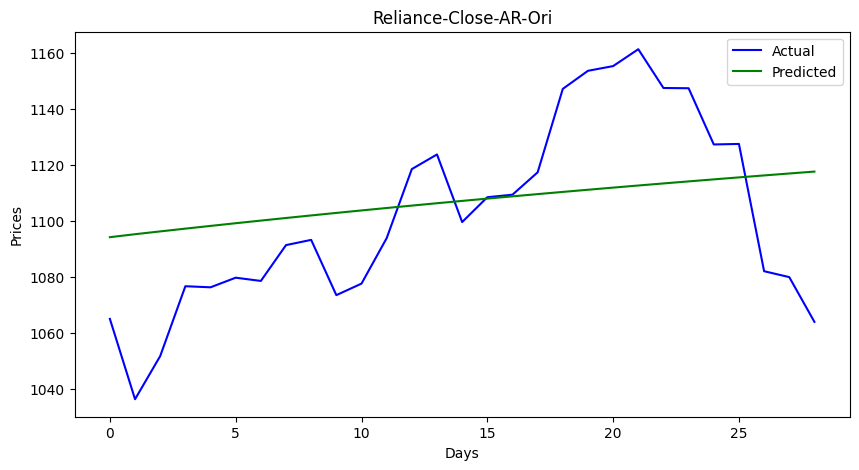

In [27]:
from stockFunctions import graph

graph(actual_stock_price_test_oriA,
      predicted_stock_price_test_oriP,
      "Actual",
      "Predicted",
      "Reliance-Close-AR-Ori",
      "Days",
      "Prices")

In [28]:
from stockFunctions import rmsemape
rmsemape(actual_stock_price_test_oriA, predicted_stock_price_test_oriP)

RMSE-Testset: 29.89072428024307
MAPE-Testset: 0.023100155370692835


### Checking the model forcast

In [33]:
forecast = model_fit.predict(len(data1), len(data1)+3)

In [34]:
forecast

array([0.60631475, 0.60841161, 0.61048117, 0.61252405])

In [35]:
from stockFunctions import conversionSingle

fTestNormTable = conversionSingle(forecast, ["Closefore"])
forecast_stock_price_test_ori = Ms.inverse_transform(fTestNormTable)
forecast_stock_price_test_oriF = conversionSingle(forecast_stock_price_test_ori, ["Closefore"])

In [36]:
forecast_stock_price_test_oriF

,Closefore
0,1118.250509
1,1118.915083
2,1119.571007
3,1120.218474


In [37]:
forecast_stock_price_test_oriF.to_csv("CloseAR.csv", index=False)

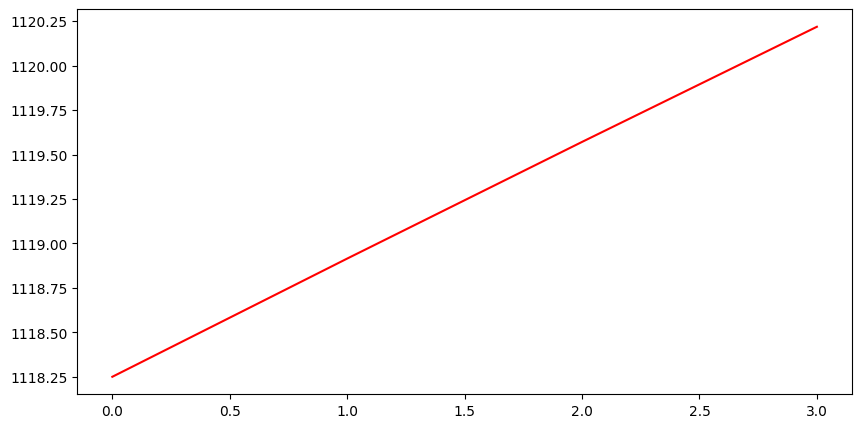

In [38]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(actual_stock_price_test_oriA[116:144], color = 'blue', label="Actual")
plt.plot(forecast_stock_price_test_oriF, color = 'red', label="Predicted")